<a href="https://colab.research.google.com/github/Ashi743/PYTORCH-DEEP-LEARNING/blob/main/CNN_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PyTorch: Data Loading and Preprocessing

To use PyTorch, we need to adapt our data loading and preprocessing steps. We'll use `torchvision.datasets.ImageFolder` to load the image data from the directory structure, and `torchvision.transforms` to apply necessary transformations like resizing, converting to tensors, and normalization. Finally, `torch.utils.data.DataLoader` will be used to create iterable data loaders for training and testing.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("playatanu/cifar10")

print("Path to dataset files:", path)

100%|██████████| 52.8M/52.8M [00:00<00:00, 175MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/playatanu/cifar10/versions/1


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

image_base_path = os.path.join(path, "CIFAR10")

train_dir_pt = os.path.join(image_base_path, 'train')
test_dir_pt = os.path.join(image_base_path, 'test')

print(f"PyTorch Training data directory: {train_dir_pt}")
print(f"PyTorch Testing data directory: {test_dir_pt}")


PyTorch Training data directory: /root/.cache/kagglehub/datasets/playatanu/cifar10/versions/1/CIFAR10/train
PyTorch Testing data directory: /root/.cache/kagglehub/datasets/playatanu/cifar10/versions/1/CIFAR10/test


In [3]:
IMG_HEIGHT_PT = 32
IMG_WIDTH_PT = 32
BATCH_SIZE_PT = 64 #32 takes time


# Define transformations for the CIFAR-10 images
# For training, we might add data augmentation (e.g., random horizontal flip)
# For now, we'll keep it simple: resize, convert to tensor, normalize
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),   # CIFAR standard
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

from torch.utils.data import DataLoader, Dataset
### CUSTOM DATASET AND DATALOADER
# Load the training dataset using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(
    root=train_dir_pt,
    transform= transform_train
)

# Load the testing dataset using ImageFolder
test_dataset = torchvision.datasets.ImageFolder(
    root=test_dir_pt,
    transform=transform_train
)

### DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_PT,
    shuffle=True,
    num_workers=2, # Changed num_workers to 0
    pin_memory=True # to copy Tensors into CUDA pinned memory before returning them
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_PT,
    shuffle=False,
    num_workers=2, # Changed num_workers to 0
    pin_memory=True
)

class_names_pt = train_dataset.classes
print(f"Class names: {class_names_pt}")

Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print(f"Number of classes: {len(class_names_pt)}")
print(f"Class names: {class_names_pt}")

image, label = train_dataset[0]
print(f"Shape of first training image: {image.shape}")
print(f"Label of first training image: {class_names_pt[label]}")

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Shape of first training image: torch.Size([3, 32, 32])
Label of first training image: airplane


#### Displaying Sample Images from the PyTorch DataLoader

Let's visualize a few images from the PyTorch DataLoader to ensure the data has been loaded and transformed correctly.

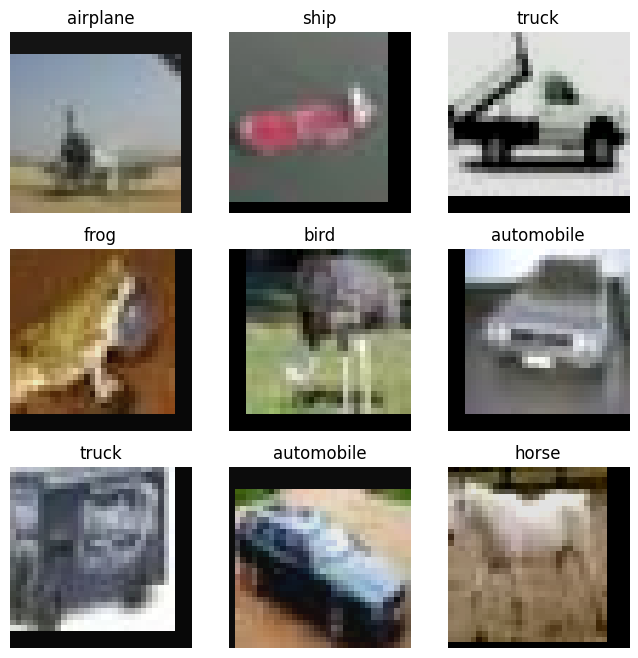

In [5]:
plt.figure(figsize=(8,8))

# Get one batch of training images and labels
dataiter = iter(train_dataloader)
images, labels = next(dataiter)

for i in range(9): # Display first 9 images from the batch
    ax = plt.subplot(3, 3, i + 1)

    # Denormalize for display (reverse of: value = (value - mean) / std)
    # For our normalization (0.5, 0.5, 0.5), (0.5, 0.5, 0.5):
    # original = (normalized * std) + mean
    # original = (images[i] * 0.5) + 0.5
    img_display = images[i] * 0.5 + 0.5  # Denormalize to [0, 1] range

    # Convert from (C, H, W) to (H, W, C) for matplotlib display
    np_img = img_display.numpy().transpose((1, 2, 0))

    plt.imshow(np_img)
    plt.title(class_names_pt[labels[i]])
    plt.axis("off")
plt.show()

In [6]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Defining a Convolutional Neural Network (CNN) in PyTorch

Now that our data is loaded and ready with PyTorch DataLoaders, let's define a simple Convolutional Neural Network (CNN) architecture. This model will consist of convolutional layers followed by pooling layers, then fully connected layers for classification.

*Think of Conv as a blender — you put in 3 fruits (R,G,B), you get out a smoothie (32 feature maps). Flatten is just pouring that smoothie into a single long tube. The original 3 fruits were already gone at the blending step.*

In [7]:
import torch.nn as nn

class simpleCNN(nn.Module):
  def __init__(self, input_features) -> None:
     super().__init__()
      #3 input channels (for RGB images)
     self.features = nn.Sequential(
        nn.Conv2d(input_features, 32 , kernel_size= 5, padding ='same' ),  #  32 output channels, 5x5 kernel
        nn.ReLU(),
        nn.BatchNorm2d(32), # 32 filters
        nn.MaxPool2d(kernel_size= 2, stride = 2 ),  #  stride =2

        nn.Conv2d(32, 64, kernel_size= 5 , padding= 'same'),  #  32 --> 64
        nn.ReLU(),
        nn.BatchNorm2d(64), # 64 filters
        nn.MaxPool2d(kernel_size= 2, stride = 2),

        nn.Conv2d(64, 128, kernel_size=3, padding='same'), #128,8,8
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size=2, stride=2)   # 8x8 → 4x4

     )

     self.classifier = nn.Sequential(
        nn.Flatten(),

        nn.Linear(128*4*4 ,128),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(64, len(class_names_pt))
     )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [8]:
#parameters
learning_rate= 0.001
epochs = 30
input_features = 3
patience = 15 # Number of epochs to wait for improvement before stopping

In [9]:
model = simpleCNN(input_features)
model.to(device)
lambda1 = 1e-4

criterion= nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                            lr= learning_rate,
                             weight_decay= lambda1)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size= 10,
    gamma= 0.5
)


In [10]:
import copy

# Initialize for early stopping
best_test_accuracy = 0.0
patience_counter = 0
best_model_state = copy.deepcopy(model.state_dict())

print("Starting training with early stopping...")

for epoch in range(epochs):
  total_epoch_loss = 0
  model.train() # Set model to training mode

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_train_loss = total_epoch_loss / len(train_dataloader)

  # --- Evaluation at the end of each epoch for early stopping ---
  model.eval() # Set model to evaluation mode
  current_total = 0
  current_correct = 0
  with torch.no_grad():
    for images, labels in test_dataloader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)

      current_total += labels.size(0)
      current_correct += (predicted == labels).sum().item()

  current_test_accuracy = current_correct / current_total

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Accuracy: {current_test_accuracy:.4f}")

  # Early stopping logic
  if current_test_accuracy > best_test_accuracy:
    best_test_accuracy = current_test_accuracy
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    print(f"  New best test accuracy: {best_test_accuracy:.4f}. Model state saved.")
  else:
    patience_counter += 1
    print(f"  Test accuracy did not improve. Patience: {patience_counter}/{patience}")
    if patience_counter >= patience:
      print(f"Early stopping at epoch {epoch+1} as test accuracy did not improve for {patience} consecutive epochs.")
      break

# Load the best model state found during training
model.load_state_dict(best_model_state)
print("Training finished. Loaded best model state.")

Starting training with early stopping...
Epoch 1/30, Train Loss: 1.5746, Test Accuracy: 0.5537
  New best test accuracy: 0.5537. Model state saved.
Epoch 2/30, Train Loss: 1.2159, Test Accuracy: 0.6152
  New best test accuracy: 0.6152. Model state saved.
Epoch 3/30, Train Loss: 1.0781, Test Accuracy: 0.6682
  New best test accuracy: 0.6682. Model state saved.
Epoch 4/30, Train Loss: 0.9983, Test Accuracy: 0.6922
  New best test accuracy: 0.6922. Model state saved.
Epoch 5/30, Train Loss: 0.9371, Test Accuracy: 0.7012
  New best test accuracy: 0.7012. Model state saved.
Epoch 6/30, Train Loss: 0.8901, Test Accuracy: 0.7218
  New best test accuracy: 0.7218. Model state saved.
Epoch 7/30, Train Loss: 0.8646, Test Accuracy: 0.7211
  Test accuracy did not improve. Patience: 1/15
Epoch 8/30, Train Loss: 0.8363, Test Accuracy: 0.7291
  New best test accuracy: 0.7291. Model state saved.
Epoch 9/30, Train Loss: 0.8039, Test Accuracy: 0.7346
  New best test accuracy: 0.7346. Model state saved.
E

In [11]:
# Final evaluation after loading the best model
model.eval()

total = 0
correct = 0

with torch.no_grad():
  for images, labels in test_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    outputs= model(images)
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

final_accuracy = correct / total
print(f"Final Test Accuracy (best model): {final_accuracy:.4f}")

Final Test Accuracy (best model): 0.7865


computation time 30 min